<a href="https://colab.research.google.com/github/lakshitasingh/Phylogenetic-Analysis-of-Cytochrome-c---Data-Analysis-Porject/blob/main/phylogenetic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.4 MB/s eta 0:00:00
Libraries installed
Imports done
21 organisms defined
  Human           (P99999) ... done
  Mouse           (P62897) ... done
  Rat             (P62898) ... done
  Horse           (P00004) ... done
  Cow             (P62893) ... done
  Dog             (P62896) ... done
  Rabbit          (P62895) ... done
  Pig             (P62894) ... done
  Chicken         (P00008) ... done
  Pigeon          (P00011) ... done
  Duck            (P00012) ... done
  Bullfrog        (P00017) ... done
  Tuna            (P00020) ... done
  Carp            (P00021) ... done
  Lamprey         (P00024) ... done
  Fruitfly        (P00025) ... done
  Silkworm        (P00029) ... done
  Baker_Yeast     (P00044) ... done
  Neurospora      (P00060) ... done
  Wheat           (P00037) ... done
  Sunflower       (P00040) ... done

 All 21 sequences downloaded → data/cytochrome_c_sequences.fasta
Loaded 21 sequences

Organism         Length
──

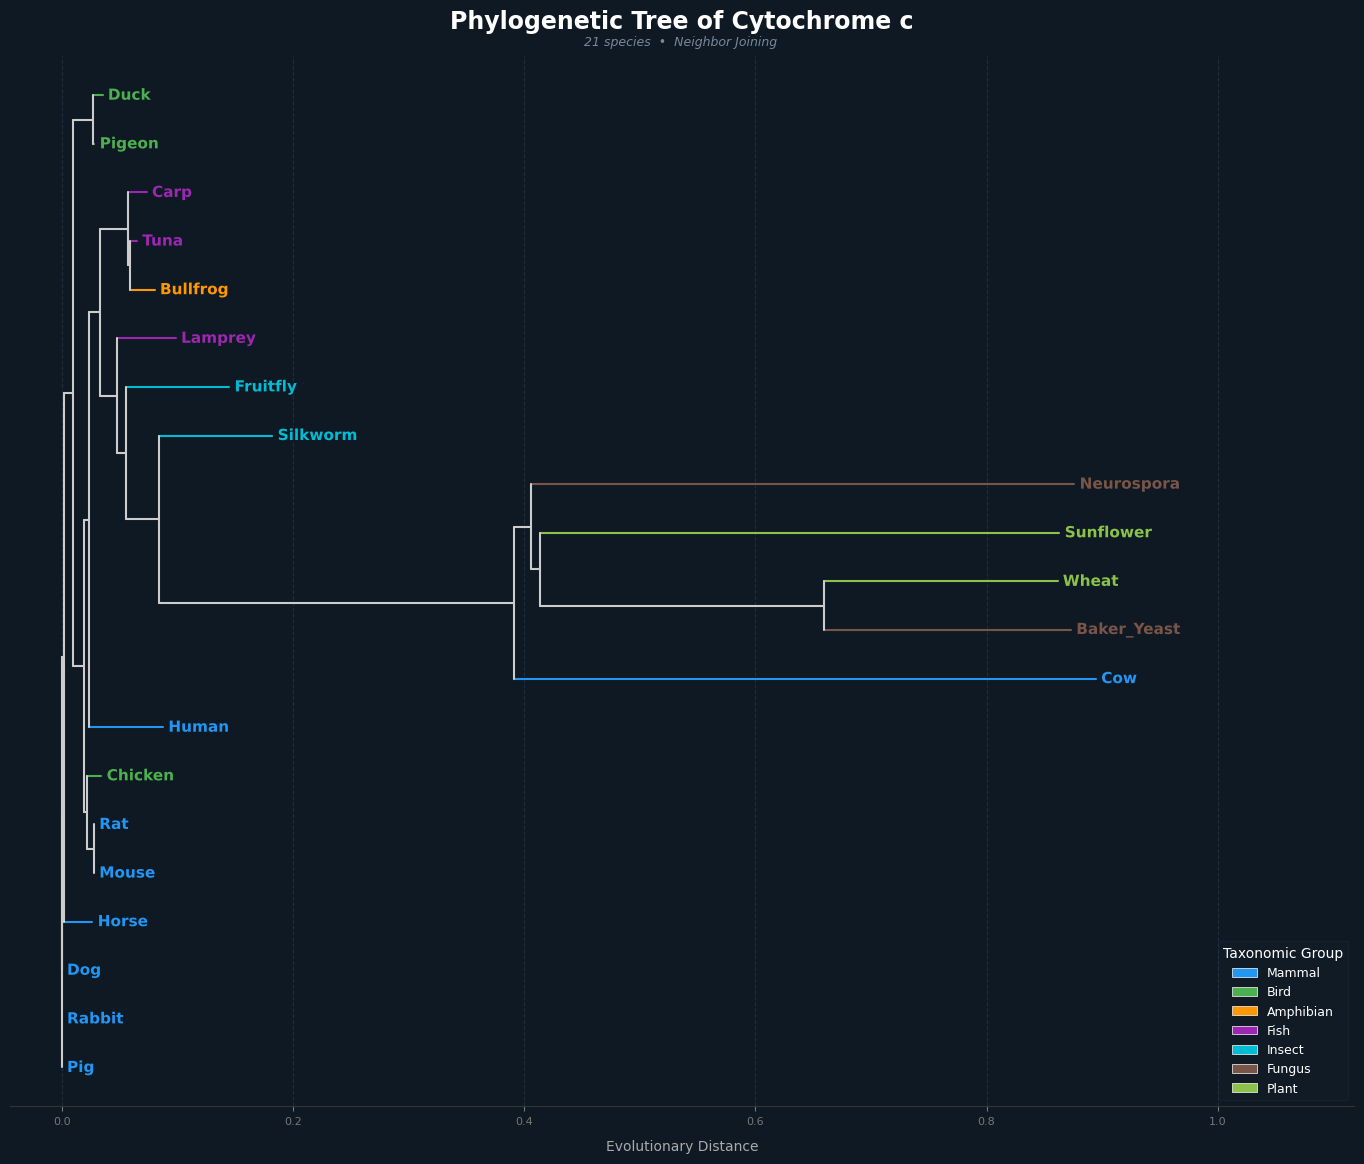

  SEQUENCE SIMILARITY AMONG CLOSELY RELATED SPECIES (Same Group)
  Pair                           Group        Similarity  Divergence
  ───────────────────────────────────────────────────────────────
  Mouse ↔ Rat                    Mammal          100.00%       0.00%
  Dog ↔ Pig                      Mammal          100.00%       0.00%
  Rabbit ↔ Pig                   Mammal          100.00%       0.00%
  Dog ↔ Rabbit                   Mammal          100.00%       0.00%
  Pigeon ↔ Duck                  Bird             99.12%       0.88%
  Horse ↔ Rabbit                 Mammal           97.35%       2.65%
  Horse ↔ Dog                    Mammal           97.35%       2.65%
  Horse ↔ Pig                    Mammal           97.35%       2.65%
  Tuna ↔ Carp                    Fish             97.35%       2.65%
  Rat ↔ Pig                      Mammal           97.35%       2.65%
  Mouse ↔ Pig                    Mammal           97.35%       2.65%
  Mouse ↔ Rabbit                 Mammal  

In [1]:
#  Library Installation

!pip install biopython matplotlib
print('Libraries installed')

# Importing and folder setup

import os
import time
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import SeqIO, AlignIO, Phylo
from Bio.Align import PairwiseAligner
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

os.makedirs('data',    exist_ok=True)
os.makedirs('results', exist_ok=True)
print('Imports done')

# Define 22 organisms
# UniProt accessions (P-numbers) are the most stable IDs for
# Me writing the order for better memory ('UniProt accession', 'Species', 'Group for color differentiation')

sequences = [
    ('P99999', 'Human',        'Mammal'),
    ('P62897', 'Mouse',        'Mammal'),
    ('P62898', 'Rat',          'Mammal'),
    ('P00004', 'Horse',        'Mammal'),
    ('P62893', 'Cow',          'Mammal'),
    ('P62896', 'Dog',          'Mammal'),
    ('P62895', 'Rabbit',       'Mammal'),
    ('P62894', 'Pig',          'Mammal'),
    ('P00008', 'Chicken',      'Bird'),
    ('P00011', 'Pigeon',       'Bird'),
    ('P00012', 'Duck',         'Bird'),
    ('P00017', 'Bullfrog',     'Amphibian'),
    ('P00020', 'Tuna',         'Fish'),
    ('P00021', 'Carp',         'Fish'),
    ('P00024', 'Lamprey',      'Fish'),
    ('P00025', 'Fruitfly',     'Insect'),
    ('P00029', 'Silkworm',     'Insect'),
    ('P00044', 'Baker_Yeast',  'Fungus'),
    ('P00060', 'Neurospora',   'Fungus'),
    ('P00037', 'Wheat',        'Plant'),
    ('P00040', 'Sunflower',    'Plant'),
]

print(f'{len(sequences)} organisms defined')

# Downloading the sequences from UniProt ───────────────────────
# For memeory remember I chose UniProt since it is more reliable than NCBI for odered protein sequences.

fasta_path = 'data/cytochrome_c_sequences.fasta'
failed     = []

with open(fasta_path, 'w') as out_file:
    for accession, label, group in sequences:
        url = f'https://www.uniprot.org/uniprot/{accession}.fasta'
        try:
            print(f'  {label:<15} ({accession}) ...', end=' ')
            with urllib.request.urlopen(url, timeout=15) as resp:
                raw   = resp.read().decode('utf-8').strip()
                lines = raw.split('\n')
                seq   = ''.join(lines[1:])   # drop the header line
                out_file.write(f'>{label}\n{seq}\n\n')
            print('done')
        except Exception as e:
            print(f'FAILED ({e})')
            failed.append(label)
        time.sleep(0.4)

if failed:
    print(f'\n These failed to download: {failed}')
else:
    print(f'\n All {len(sequences)} sequences downloaded → {fasta_path}')

# Preview the sequences once

records = list(SeqIO.parse(fasta_path, 'fasta'))
print(f'Loaded {len(records)} sequences\n')
print(f'{"Organism":<16} {"Length":>6}')
print('─' * 25)
for rec in records:
    print(f'{rec.id:<16} {len(rec.seq):>6}')

# Multiple Sequence Alignment
# Aligns all sequences to the Human reference using global alignment. Biopython already has it so good

def align_all(records):
    aligner                  = PairwiseAligner()
    aligner.mode             = 'global'
    aligner.match_score      =  2
    aligner.mismatch_score   = -1
    aligner.open_gap_score   = -2
    aligner.extend_gap_score = -0.5

    reference = str(records[0].seq)
    aligned   = []

    for rec in records:
        if str(rec.seq) == reference:
            aligned.append(SeqRecord(Seq(reference), id=rec.id))
        else:
            aln  = aligner.align(reference, str(rec.seq))[0]
            aseq = str(aln[1])
            aligned.append(SeqRecord(Seq(aseq), id=rec.id))

    max_len = max(len(r.seq) for r in aligned)
    return [
        SeqRecord(Seq(str(r.seq).ljust(max_len, '-')), id=r.id)
        for r in aligned
    ]

print('Aligning ...')
aligned_records = align_all(records)
aligned_path    = 'results/cytochrome_c_aligned.fasta'
SeqIO.write(aligned_records, aligned_path, 'fasta')
print(f'Aligned {len(aligned_records)} sequences ({len(aligned_records[0].seq)} columns)')

# Finally building the phylogenetic tree
# Distance matrix is Neighbor Joining tree

alignment       = AlignIO.read(aligned_path, 'fasta')
calculator      = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)
constructor     = DistanceTreeConstructor(calculator, 'nj')
tree            = constructor.build_tree(alignment)

Phylo.write(tree, 'results/cytochrome_c_tree.nwk', 'newick')
print('Tree built : results/cytochrome_c_tree.nwk')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

# Color
GROUP_COLORS = {
    'Mammal'    : '#2196F3',
    'Bird'      : '#4CAF50',
    'Amphibian' : '#FF9800',
    'Fish'      : '#9C27B0',
    'Insect'    : '#00BCD4',
    'Fungus'    : '#795548',
    'Plant'     : '#8BC34A',
}
label_to_group = {label: group for _, label, group in sequences}
label_to_color = {label: GROUP_COLORS[group] for label, group in label_to_group.items()}

# Assign colors to clades; strip Inner labels
for clade in tree.find_clades():
    if clade.name and clade.name in label_to_color:
        clade.color = label_to_color[clade.name]
    elif clade.name and 'Inner' in str(clade.name):
        clade.name  = None
        clade.color = '#CCCCCC'

leaves = [c.name for c in tree.find_clades(order='level') if c.is_terminal()]
n      = len(leaves)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0F1923')   # dark navy background
ax.set_facecolor('#0F1923')

Phylo.draw(
    tree,
    axes        = ax,
    do_show     = False,
    label_func  = lambda c: c.name if c.name else '',
)

#  Restyle every line in the plot
for line in ax.get_lines():
    line.set_linewidth(1.6)
    line.set_alpha(0.85)

# Restyle all text labels
for text in ax.texts:
    name = text.get_text().strip()
    if name in label_to_color:
        text.set_color(label_to_color[name])
        text.set_fontsize(11)
        text.set_fontweight('bold')
        text.set_path_effects([
            pe.withStroke(linewidth=2.5, foreground='#0F1923')
        ])
    else:
        text.set_visible(False)   # hide any leftover internal labels

# Axes styling
ax.set_title(
    'Phylogenetic Tree of Cytochrome c',
    fontsize    = 17,
    fontweight  = 'bold',
    color       = 'white',
    pad         = 20,
    loc         = 'center',
)
ax.set_xlabel('Evolutionary Distance', fontsize=10, color='#AAAAAA', labelpad=10)
ax.yaxis.set_visible(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#333333')
ax.tick_params(axis='x', colors='#777777', labelsize=8)
ax.xaxis.grid(True, color='#1E2D3D', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

# Legend
legend_patches = [
    mpatches.Patch(facecolor=color, edgecolor='white', linewidth=0.5, label=group)
    for group, color in GROUP_COLORS.items()
]
legend = ax.legend(
    handles        = legend_patches,
    title          = 'Taxonomic Group',
    title_fontsize = 10,
    fontsize       = 9,
    loc            = 'lower right',
    framealpha     = 0.15,
    facecolor      = '#1A2A3A',
    edgecolor      = '#334455',
    labelcolor     = 'white',
)
legend.get_title().set_color('white')

#  Species count subtitle
ax.text(
    0.5, 1.01,
    f'{n} species  •  Neighbor Joining ',
    transform   = ax.transAxes,
    ha          = 'center',
    fontsize    = 9,
    color       = '#778899',
    style       = 'italic',
)

plt.tight_layout(pad=2)
plt.savefig(
    'results/cytochrome_c_tree.png',
    dpi         = 200,
    bbox_inches = 'tight',
    facecolor   = '#0F1923',
)
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# Similarity table from the distance matrix
names    = distance_matrix.names
n        = len(names)
dist_arr = np.array([[distance_matrix[i, j] for j in range(n)] for i in range(n)])
sim_arr  = (1 - dist_arr) * 100          # convert distance → % similarity

sim_df = pd.DataFrame(sim_arr, index=names, columns=names).round(2)

# Separating pairs into intra-group vs inter-group ────────
label_to_group = {label: group for _, label, group in sequences}

intra_pairs = []   # same taxonomic group : "closely related"
inter_pairs = []   # different group  : "distant taxa"

for s1, s2 in combinations(names, 2):
    g1  = label_to_group.get(s1, '?')
    g2  = label_to_group.get(s2, '?')
    sim = sim_df.loc[s1, s2]
    div = 100 - sim                       # divergence = 100 − similarity

    row = {
        'Species_1'   : s1,
        'Species_2'   : s2,
        'Group_1'     : g1,
        'Group_2'     : g2,
        'Similarity_%': round(sim, 2),
        'Divergence_%': round(div, 2),
    }

    if g1 == g2:
        intra_pairs.append(row)
    else:
        inter_pairs.append(row)

intra_df = pd.DataFrame(intra_pairs).sort_values('Similarity_%', ascending=False)
inter_df = pd.DataFrame(inter_pairs).sort_values('Similarity_%', ascending=False)

print('=' * 65)
print('  SEQUENCE SIMILARITY AMONG CLOSELY RELATED SPECIES (Same Group)')
print('=' * 65)
print(f"  {'Pair':<30} {'Group':<12} {'Similarity':>10}  {'Divergence':>10}")
print('  ' + '─' * 63)
for _, row in intra_df.iterrows():
    pair = f"{row['Species_1']} ↔ {row['Species_2']}"
    print(f"  {pair:<30} {row['Group_1']:<12} {row['Similarity_%']:>9.2f}%  {row['Divergence_%']:>9.2f}%")

print()
print('=' * 65)
print('  SEQUENCE DIVERGENCE AMONG DISTANT TAXA (Different Groups)')
print('  Showing most divergent 20 pairs')
print('=' * 65)
print(f"  {'Pair':<34} {'Similarity':>10}  {'Divergence':>10}")
print('  ' + '─' * 63)
for _, row in inter_df.tail(20).iloc[::-1].iterrows():
    pair = f"{row['Species_1']} ↔ {row['Species_2']}"
    print(f"  {pair:<34} {row['Similarity_%']:>9.2f}%  {row['Divergence_%']:>9.2f}%")

print()
print('=' * 65)
print('  AVERAGE SIMILARITY WITHIN EACH TAXONOMIC GROUP')
print('=' * 65)
if not intra_df.empty:
    group_avg = (
        intra_df.groupby('Group_1')['Similarity_%']
        .agg(['mean', 'min', 'max'])
        .round(2)
        .rename(columns={'mean': 'Mean %', 'min': 'Min %', 'max': 'Max %'})
        .sort_values('Mean %', ascending=False)
    )
    print(group_avg.to_string())
else:
    print('  (Not enough intra-group pairs to compute averages)')

print()
print(f'  Overall mean similarity (all {len(names)} species): '
      f'{sim_arr[np.triu_indices(n, k=1)].mean():.2f}%')
print(f'  Overall mean divergence                           : '
      f'{(100 - sim_arr[np.triu_indices(n, k=1)].mean()):.2f}%')